In [1]:
pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer


In [4]:
documents = [
    "I love machine learning",
    "Machine learning is interesting",
    "I love natural language processing",
    "NLP is a part of artificial intelligence",
    "Machine learning uses data",
    "Natural language processing uses text data",
    "Artificial intelligence is powerful",
    "I study machine learning",
    "Text processing is useful",
    "I love artificial intelligence"
]

print("Number Number Documents : ",len(documents))

Number Number Documents :  10


In [14]:
words = np.array([["machine"],["learning"],["NLP"],["data"]])

encoder = OneHotEncoder(sparse_output = False)
one_hot = encoder.fit_transform(words)

print("One hot Encoding : \n")
print(pd.DataFrame(one_hot,index=words.flatten(),columns=encoder.categories_[0]))

One hot Encoding : 

          NLP  data  learning  machine
machine   0.0   0.0       0.0      1.0
learning  0.0   0.0       1.0      0.0
NLP       1.0   0.0       0.0      0.0
data      0.0   1.0       0.0      0.0


In [22]:
# 2. BAG OF WORDS

bow_vec = CountVectorizer()

bow_mat = bow_vec.fit_transform(documents)

print("Bag of Words Vocabulary :\n")
print(bow_vec.get_feature_names_out())

print("\nBag of Words Matrix :")
print(bow_mat.toarray())

Bag of Words Vocabulary :

['artificial' 'data' 'intelligence' 'interesting' 'is' 'language'
 'learning' 'love' 'machine' 'natural' 'nlp' 'of' 'part' 'powerful'
 'processing' 'study' 'text' 'useful' 'uses']

Bag of Words Matrix :
[[0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0]
 [1 0 1 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 1]
 [1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0]
 [1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]]


In [26]:
# 3. DOCUMENT-TERM MATRIX

dmt = pd.DataFrame( bow_mat.toarray(), columns = bow_vec.get_feature_names_out())

print("Document Term Matrix : ")
print(dmt)

Document Term Matrix : 
   artificial  data  intelligence  interesting  is  language  learning  love  \
0           0     0             0            0   0         0         1     1   
1           0     0             0            1   1         0         1     0   
2           0     0             0            0   0         1         0     1   
3           1     0             1            0   1         0         0     0   
4           0     1             0            0   0         0         1     0   
5           0     1             0            0   0         1         0     0   
6           1     0             1            0   1         0         0     0   
7           0     0             0            0   0         0         1     0   
8           0     0             0            0   1         0         0     0   
9           1     0             1            0   0         0         0     1   

   machine  natural  nlp  of  part  powerful  processing  study  text  useful  \
0        1    

In [28]:
# 4. TF-IDF

tfidf_vec = TfidfVectorizer()

tfidf_mat = tfidf_vec.fit_transform(documents)

tfidf_df=pd.DataFrame( tfidf_mat.toarray(), columns = tfidf_vec.get_feature_names_out())

print("TF-IDF MATRIX : ")
print(tfidf_df)

TF-IDF MATRIX : 
   artificial      data  intelligence  interesting        is  language  \
0    0.000000  0.000000      0.000000     0.000000  0.000000  0.000000   
1    0.000000  0.000000      0.000000     0.657714  0.434899  0.000000   
2    0.000000  0.000000      0.000000     0.000000  0.000000  0.532183   
3    0.348915  0.000000      0.348915     0.000000  0.310211  0.000000   
4    0.000000  0.558141      0.000000     0.000000  0.000000  0.000000   
5    0.000000  0.416471      0.000000     0.000000  0.000000  0.416471   
6    0.466337  0.000000      0.466337     0.000000  0.414607  0.000000   
7    0.000000  0.000000      0.000000     0.000000  0.000000  0.000000   
8    0.000000  0.000000      0.000000     0.000000  0.401445  0.000000   
9    0.577350  0.000000      0.577350     0.000000  0.000000  0.000000   

   learning      love   machine   natural       nlp        of      part  \
0  0.553416  0.622465  0.553416  0.000000  0.000000  0.000000  0.000000   
1  0.434899  0.000

In [35]:
# 5. FEATURE DIMENSIONALITY

rows, columns = bow_mat.shape

print("Feature Dimentionality : \n")
print("NO. of Ducuments",rows)
print("Number Of Features",columns,"\n")

Feature Dimentionality : 

NO. of Ducuments 10
Number Of Features 19 



In [38]:
# 6. SPARSITY

total_ele = bow_mat.shape[0] * bow_mat.shape[1]
zero_ele = total_ele - bow_mat.count_nonzero()

spar = (zero_ele / total_ele) * 100

print("\nSparsity:")
print(round(spar, 2), "%")



Sparsity:
78.42 %


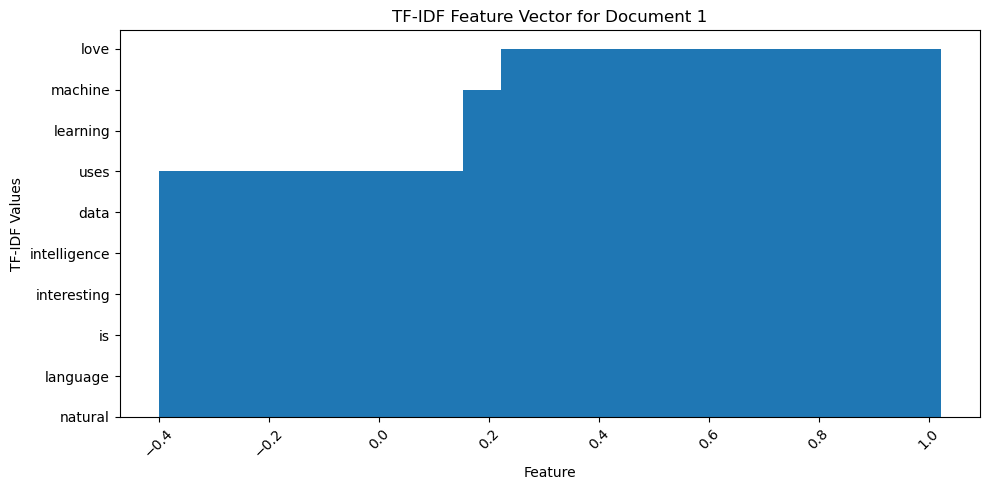

In [43]:
feature_vec =tfidf_mat[0].toarray().flatten()

feature = tfidf_vec.get_feature_names_out()

top_indx = np.argsort(feature_vec)[-10:]

plt.figure(figsize=(10,5))

plt.bar( feature_vec[top_indx],feature[top_indx])


plt.xlabel("Feature")
plt.ylabel("TF-IDF Values")
plt.title("TF-IDF Feature Vector for Document 1")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
